In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input, Bidirectional, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from lightgbm import LGBMClassifier, LGBMRegressor

# Part 1 Data Description

In [ ]:
# --- Load the dataset ---
data = pd.read_csv('BTCUSDT.csv', parse_dates=['timestamp'])

# --- Clean the dataset ---
# Drop columns not needed
cols_to_drop = ['close_time', 'ignore']
data.drop(columns=[col for col in cols_to_drop if col in data.columns], inplace=True)

# Sort by time and remove any missing values
data = data.sort_values('timestamp').dropna().reset_index(drop=True)

# Set index for time-based slicing
data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')
data.set_index('timestamp', inplace=True)

In [ ]:
data = data[data.index >= '2020-01-01']

In [ ]:
data.head()

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
timestamp,,,,,,,,,
2020-01-01 00:00:00,7195.24,7196.25,7183.14,7186.68,51.642812,371233.518355,493,19.598230,140888.414283
2020-01-01 00:01:00,7187.67,7188.06,7182.20,7184.03,7.248148,52080.127788,135,2.031772,14599.211924
2020-01-01 00:02:00,7184.41,7184.71,7180.26,7182.43,11.681677,83903.741635,202,5.479244,39357.081776
2020-01-01 00:03:00,7183.83,7188.94,7182.49,7185.94,10.025391,72033.226649,136,3.294966,23680.571924
2020-01-01 00:04:00,7185.54,7185.54,7178.64,7179.78,14.911105,107066.521825,161,2.369033,17012.015138


# Part 2: Data Processing

In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2765515 entries, 2020-01-01 00:00:00 to 2025-04-06 03:00:00
Data columns (total 9 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   open                          float64
 1   high                          float64
 2   low                           float64
 3   close                         float64
 4   volume                        float64
 5   quote_asset_volume            float64
 6   number_of_trades              int64  
 7   taker_buy_base_asset_volume   float64
 8   taker_buy_quote_asset_volume  float64
dtypes: float64(8), int64(1)
memory usage: 211.0 MB


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
count,2.765515e+06,2.765515e+06,2.765515e+06,2.765515e+06,2.765515e+06,2.765515e+06,2.765515e+06,2.765515e+06,2.765515e+06
mean,3.908708e+04,3.910582e+04,3.906824e+04,3.908711e+04,5.673262e+01,1.683601e+06,1.648169e+03,2.802896e+01,8.316424e+05
std,2.402742e+04,2.403715e+04,2.401756e+04,2.402743e+04,1.022564e+02,2.728595e+06,2.284065e+03,5.210205e+01,1.418631e+06
min,3.810000e+03,3.900000e+03,3.782130e+03,3.810780e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.016262e+04,2.017483e+04,2.015123e+04,2.016260e+04,1.212296e+01,3.710830e+05,4.610000e+02,5.278910e+00,1.583197e+05
50%,3.462948e+04,3.465294e+04,3.460552e+04,3.462965e+04,2.572370e+01,8.684725e+05,8.480000e+02,1.222670e+01,4.099337e+05
75%,5.658403e+04,5.661782e+04,5.655002e+04,5.658406e+04,5.874573e+01,1.938706e+06,1.883000e+03,2.909351e+01,9.567905e+05
max,1.091859e+05,1.095880e+05,1.089451e+05,1.091942e+05,5.877775e+03,2.598501e+08,1.497130e+05,3.537453e+03,1.004182e+08


#### Add Technical Indicators

In [ ]:
# Create return columns
data['return'] = data['close'].pct_change()
data['future_return'] = data['close'].shift(-1) / data['close'] - 1

# Create target variable: 1 if next return is positive, else 0
data['target'] = (data['future_return'] > 0).astype(int)

In [ ]:
# Technical Indicators
# 1. MACD & MACD_DIFF
ema_12 = data['close'].ewm(span=12, adjust=False).mean()
ema_26 = data['close'].ewm(span=26, adjust=False).mean()
data['macd'] = ema_12 - ema_26
data['macd_diff'] = data['macd'] - data['macd'].ewm(span=9, adjust=False).mean()

# 2. RSI (Relative Strength Index)
delta = data['close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
data['rsi_14'] = 100 - (100 / (1 + rs))

# 3. SMA10 (Short Moving Average)
data['sma_10'] = data['close'].rolling(window=10).mean()

# 4. Bollinger %B
rolling_std = data['close'].rolling(window=20).std()
sma_20 = data['close'].rolling(window=20).mean()
bb_upper = sma_20 + (2 * rolling_std)
bb_lower = sma_20 - (2 * rolling_std)
data['bb_ratio'] = (data['close'] - bb_lower) / (bb_upper - bb_lower)

# 5. ATR (Average True Range)
data['H-L'] = data['high'] - data['low']
data['H-PC'] = (data['high'] - data['close'].shift(1)).abs()
data['L-PC'] = (data['low'] - data['close'].shift(1)).abs()
data['TR'] = data[['H-L', 'H-PC', 'L-PC']].max(axis=1)
data['atr'] = data['TR'].rolling(window=14, min_periods=14).mean()
data.drop(columns=['H-L', 'H-PC', 'L-PC', 'TR'], inplace=True)

# 6. OBV (On-Balance Volume)
obv = [0]
for i in range(1, len(data)):
    if data['close'].iloc[i] > data['close'].iloc[i - 1]:
        obv.append(obv[-1] + data['volume'].iloc[i])
    elif data['close'].iloc[i] < data['close'].iloc[i - 1]:
        obv.append(obv[-1] - data['volume'].iloc[i])
    else:
        obv.append(obv[-1])
data['obv'] = obv



In [ ]:
#  Construct prediction targets for different horizons
data['target_2min'] = (data['close'].shift(-2) > data['close']).astype(int)
data['target_5min'] = (data['close'].shift(-5) > data['close']).astype(int)
data['target_15min'] = (data['close'].shift(-15) > data['close']).astype(int)
data['target_30min'] = (data['close'].shift(-30) > data['close']).astype(int)
data['target_60min'] = (data['close'].shift(-60) > data['close']).astype(int)

# Volume-based features
data['log_volume'] = np.log1p(data['volume'])
data['mean_volume_10'] = data['volume'].rolling(10).mean()
data['volume_ratio'] = data['volume'] / data['mean_volume_10']
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

In [ ]:
data['close_t1'] = data['close'].shift(1)
data['macd_t1'] = data['macd'].shift(1)
data['rolling_std_5'] = data['close'].rolling(5).std()
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek

In [ ]:
# Drop any new NaN values created by indicator calculations
data = data.dropna().reset_index()
data.set_index('timestamp', inplace=True)

In [ ]:
drop_cols = [
    'return', 'future_return',
    'quote_asset_volume', 'number_of_trades',
    'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume'
]

data.drop(columns=[col for col in drop_cols if col in data.columns], inplace=True)


In [ ]:
data.head()

,open,high,low,close,volume,target,macd,macd_diff,rsi_14,sma_10,...,target_30min,target_60min,log_volume,mean_volume_10,volume_ratio,close_t1,macd_t1,rolling_std_5,hour,dayofweek
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:23:00,7180.16,7180.80,7179.43,7179.98,6.340001,0,-1.610329,-0.257693,31.411331,7180.236,...,0,1,1.993339,7.828055,0.809908,7180.77,-1.624411,2.289181,0,2
2020-01-01 00:24:00,7179.48,7180.90,7175.47,7176.96,12.051590,1,-1.821857,-0.375377,32.155113,7179.835,...,1,1,2.568910,8.122033,1.483815,7179.98,-1.610329,2.533521,0,2
2020-01-01 00:25:00,7177.59,7184.53,7176.92,7182.55,12.926262,0,-1.520896,-0.059533,40.772918,7179.784,...,0,1,2.633776,8.663936,1.491962,7176.96,-1.821857,2.247783,0,2
2020-01-01 00:26:00,7182.53,7185.56,7178.96,7180.44,4.567109,0,-1.436087,0.020221,40.266272,7179.699,...,0,1,1.716876,8.575912,0.532551,7182.55,-1.520896,2.026882,0,2
2020-01-01 00:27:00,7179.77,7180.27,7176.11,7178.72,16.021720,0,-1.490483,-0.027341,44.506213,7179.548,...,1,1,2.834490,9.580317,1.672358,7180.44,-1.436087,2.074367,0,2


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2764810 entries, 2020-01-01 00:23:00 to 2025-04-06 02:59:00
Data columns (total 26 columns):
 #   Column          Dtype  
---  ------          -----  
 0   open            float64
 1   high            float64
 2   low             float64
 3   close           float64
 4   volume          float64
 5   target          int64  
 6   macd            float64
 7   macd_diff       float64
 8   rsi_14          float64
 9   sma_10          float64
 10  bb_ratio        float64
 11  atr             float64
 12  obv             float64
 13  target_2min     int64  
 14  target_5min     int64  
 15  target_15min    int64  
 16  target_30min    int64  
 17  target_60min    int64  
 18  log_volume      float64
 19  mean_volume_10  float64
 20  volume_ratio    float64
 21  close_t1        float64
 22  macd_t1         float64
 23  rolling_std_5   float64
 24  hour            int32  
 25  dayofweek       int32  
dtypes: float64(18), int32(2), int64(6)
me

,open,high,low,close,volume,target,macd,macd_diff,rsi_14,sma_10,...,target_30min,target_60min,log_volume,mean_volume_10,volume_ratio,close_t1,macd_t1,rolling_std_5,hour,dayofweek
count,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,...,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06,2.764810e+06
mean,3.908610e+04,3.910484e+04,3.906725e+04,3.908612e+04,5.674093e+01,4.907968e-01,1.891759e-01,-1.338498e-03,5.020326e+01,3.908601e+04,...,5.051316e-01,5.079394e-01,3.358591e+00,5.674280e+01,1.014439e+00,3.908610e+04,1.891850e-01,2.469387e+01,1.150301e+01,3.000654e+00
std,2.402827e+04,2.403801e+04,2.401841e+04,2.402828e+04,1.022613e+02,4.999154e-01,4.368761e+01,1.329775e+01,1.639073e+01,2.402819e+04,...,4.999738e-01,4.999371e-01,1.135556e+00,8.645695e+01,6.690500e-01,2.402827e+04,4.368760e+01,3.166994e+01,6.922745e+00,1.998654e+00
min,3.810000e+03,3.900000e+03,3.782130e+03,3.810780e+03,0.000000e+00,0.000000e+00,-1.411865e+03,-4.936542e+02,0.000000e+00,3.933206e+03,...,0.000000e+00,0.000000e+00,0.000000e+00,4.343240e-01,0.000000e+00,3.810780e+03,-1.411865e+03,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.016076e+04,2.017257e+04,2.014944e+04,2.016071e+04,1.212797e+01,0.000000e+00,-1.070351e+01,-3.650259e+00,3.867178e+01,2.016097e+04,...,0.000000e+00,0.000000e+00,2.574745e+00,1.520788e+01,6.019518e-01,2.016069e+04,-1.070342e+01,6.229614e+00,6.000000e+00,1.000000e+00
50%,3.462913e+04,3.465254e+04,3.460507e+04,3.462911e+04,2.572971e+01,0.000000e+00,2.069165e-01,-3.116736e-02,5.011962e+01,3.463040e+04,...,1.000000e+00,1.000000e+00,3.285776e+00,2.887247e+01,8.557186e-01,3.462908e+04,2.069165e-01,1.498657e+01,1.200000e+01,3.000000e+00
75%,5.658201e+04,5.661593e+04,5.654997e+04,5.658203e+04,5.875603e+01,1.000000e+00,1.146799e+01,3.542332e+00,6.166330e+01,5.658083e+04,...,1.000000e+00,1.000000e+00,4.090270e+00,6.114537e+01,1.220093e+00,5.658201e+04,1.146799e+01,3.164702e+01,1.800000e+01,5.000000e+00
max,1.091859e+05,1.095880e+05,1.089451e+05,1.091942e+05,5.877775e+03,1.000000e+00,1.365472e+03,5.123405e+02,9.999893e+01,1.089020e+05,...,1.000000e+00,1.000000e+00,8.679104e+00,2.897922e+03,1.000000e+01,1.091942e+05,1.365472e+03,2.236041e+03,2.300000e+01,6.000000e+00


# Part 3: Trend Prediction

In [ ]:
# Split the data
train_size = 0.8  # 80% and 20%
split_index = int(len(data) * train_size)

train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]


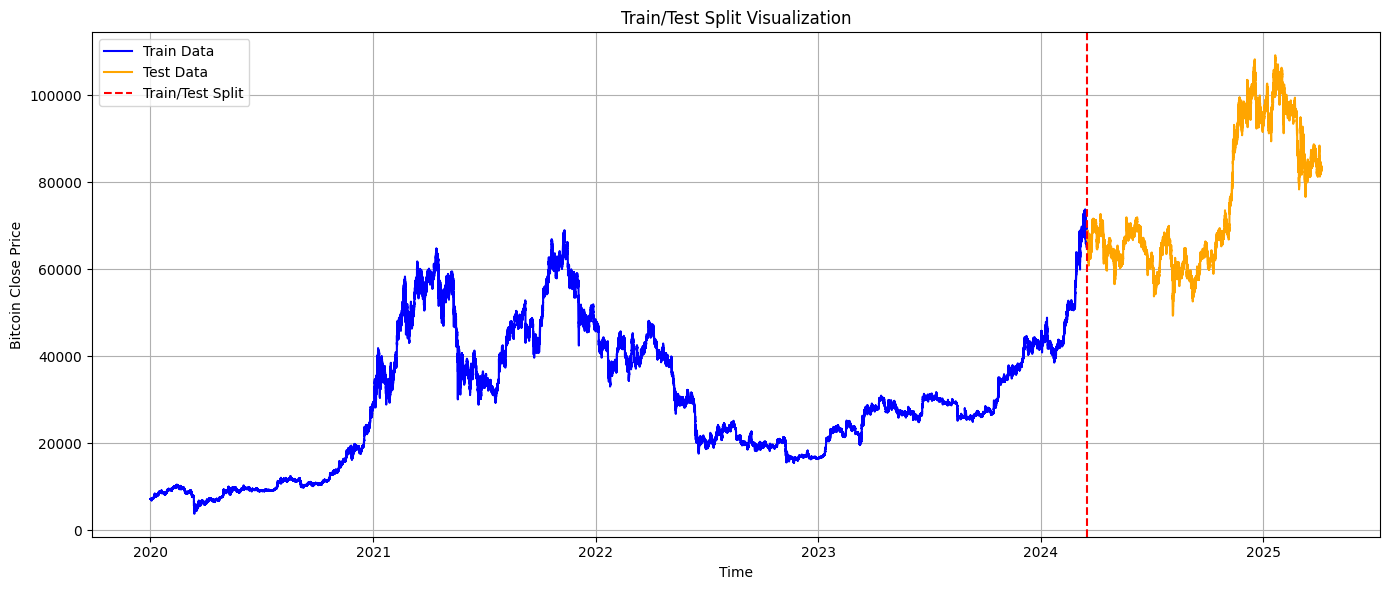

In [ ]:
# Plot the Data Splits
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data['close'], label='Train Data', color='blue')
plt.plot(test_data.index, test_data['close'], label='Test Data', color='orange')
plt.axvline(x=test_data.index[0], color='red', linestyle='--', label='Train/Test Split')
plt.title('Train/Test Split Visualization')
plt.xlabel('Time')
plt.ylabel('Bitcoin Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Define Target and Feature Set
feature_cols = ['macd', 'macd_diff', 'rsi_14', 'sma_10', 'bb_ratio', 'atr', 'obv','log_volume',
                'volume_ratio', 'close_t1', 'macd_t1', 'rolling_std_5', 'hour', 'dayofweek']

## Short-term Predict

### Basic ML model

In [ ]:
def train_basic_models(train_data, test_data, feature_cols, horizons=[2, 5, 15, 30, 60]):
    results = []
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(train_data[feature_cols])
    X_test_scaled = scaler.transform(test_data[feature_cols])

    for h in horizons:
        label_col = f'target_{h}min'
        y_train = train_data[label_col]
        y_test = test_data[label_col]

        row = {'Horizon': f'{h}min'}

        # Logistic
        model_lr = LogisticRegression(max_iter=3000)
        model_lr.fit(X_train_scaled, y_train)
        y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]
        row['Logistic_AUC'] = roc_auc_score(y_test, y_prob_lr)
        row['Logistic_Acc'] = accuracy_score(y_test, y_prob_lr > 0.5)

        # LightGBM
        model_lgb = LGBMClassifier(n_estimators=100, random_state=42)
        model_lgb.fit(X_train_scaled, y_train)
        y_prob_lgb = model_lgb.predict_proba(X_test_scaled)[:, 1]
        row['LightGBM_AUC'] = roc_auc_score(y_test, y_prob_lgb)
        row['LightGBM_Acc'] = accuracy_score(y_test, y_prob_lgb > 0.5)

        # XGBoost (use GPU if available)
        model_xgb = XGBClassifier(n_estimators=100, tree_method='hist', random_state=42)
        model_xgb.fit(X_train_scaled, y_train)

        # Stacking
        stack_model = StackingClassifier(
            estimators=[('lr', model_lr), ('lgb', model_lgb), ('xgb', model_xgb)],
            final_estimator=LogisticRegression()
        )
        stack_model.fit(X_train_scaled, y_train)
        y_prob_stack = stack_model.predict_proba(X_test_scaled)[:, 1]
        row['Stacking_AUC'] = roc_auc_score(y_test, y_prob_stack)
        row['Stacking_Acc'] = accuracy_score(y_test, y_prob_stack > 0.5)

        results.append(row)
    return pd.DataFrame(results)

In [ ]:
df_basic = train_basic_models(train_data, test_data, feature_cols)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1099732, number of negative: 1112116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 2211848, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497201 -> initscore=-0.011198
[LightGBM] [Info] Start training from score -0.011198


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1099732, number of negative: 1112116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 2211848, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.497201 -> initscore=-0.011198
[LightGBM] [Info] Start training from score -0.011198


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 899075, number of negative: 870404
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 1769479, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508102 -> initscore=0.032409
[LightGBM] [Info] Start training from score 0.032409


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 899075, number of negative: 870404
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015946 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 1769479, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508102 -> initscore=0.032409
[LightGBM] [Info] Start training from score 0.032409


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### MLP

In [ ]:
def build_mlp(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128), BatchNormalization(), LeakyReLU(), Dropout(0.3),
        Dense(64), BatchNormalization(), LeakyReLU(), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC', 'accuracy'])
    return model

def train_mlp_models(train_data, test_data, feature_cols, horizons=[2, 5, 15, 30, 60]):
    results = []
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_data[feature_cols])
    X_test_scaled = scaler.transform(test_data[feature_cols])

    for h in horizons:
        label_col = f'target_{h}min'
        y_train = train_data[label_col]
        y_test = test_data[label_col]

        model = build_mlp(X_train_scaled.shape[1])
        early_stop = EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max')
        reduce_lr = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2, mode='max')

        model.fit(X_train_scaled, y_train, epochs=30, batch_size=128,
                  validation_split=0.1, callbacks=[early_stop, reduce_lr], verbose=0)

        y_pred = model.predict(X_test_scaled).ravel()
        results.append({
            'Horizon': f'{h}min',
            'MLP_AUC': roc_auc_score(y_test, y_pred),
            'MLP_Acc': accuracy_score(y_test, y_pred > 0.5)
        })
    return pd.DataFrame(results)

In [ ]:
df_mlp = train_mlp_models(train_data, test_data, feature_cols)

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


17281/17281 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


17281/17281 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


17281/17281 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


17281/17281 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


17281/17281 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


In [ ]:
print(df_basic)

  Horizon  Logistic_AUC  Logistic_Acc  LightGBM_AUC  LightGBM_Acc  \
0    2min      0.512866      0.509136      0.516483      0.509876   
1    5min      0.519275      0.512587      0.519560      0.512449   
2   15min      0.527192      0.518063      0.514791      0.510834   
3   30min      0.525188      0.515319      0.512390      0.509449   
4   60min      0.526081      0.516155      0.509952      0.509720   

   Stacking_AUC  Stacking_Acc  
0      0.511477      0.506612  
1      0.518597      0.513156  
2      0.526502      0.518193  
3      0.524613      0.515639  
4      0.525375      0.515299  


In [ ]:
print(df_mlp)

  Horizon   MLP_AUC   MLP_Acc
0    2min  0.518280  0.513270
1    5min  0.521117  0.511368
2   15min  0.527405  0.518021
3   30min  0.519081  0.501526
4   60min  0.523975  0.500166


In [ ]:
df_all = df_basic.merge(df_mlp, on='Horizon')
display(df_all)


,Horizon,Logistic_AUC,Logistic_Acc,LightGBM_AUC,LightGBM_Acc,Stacking_AUC,Stacking_Acc,MLP_AUC,MLP_Acc
0,2min,0.512866,0.509136,0.516483,0.509876,0.511477,0.506612,0.518280,0.513270
1,5min,0.519275,0.512587,0.519560,0.512449,0.518597,0.513156,0.521117,0.511368
2,15min,0.527192,0.518063,0.514791,0.510834,0.526502,0.518193,0.527405,0.518021
3,30min,0.525188,0.515319,0.512390,0.509449,0.524613,0.515639,0.519081,0.501526
4,60min,0.526081,0.516155,0.509952,0.509720,0.525375,0.515299,0.523975,0.500166


### Long-term Predict

### Basic ML Model

In [ ]:
# Step 1:longterm target data
def create_longterm_direction_targets(data, close_col='close', future_days=[1, 5, 10, 20, 30]):
    minutes_per_day = 1440
    for day in future_days:
        shift = day * minutes_per_day
        data[f'target_{day}d'] = (data[close_col].shift(-shift) > data[close_col]).astype(int)
    return data

# Step 2:  basic models：Logistic, LightGBM, Stacking
def train_basic_models_longterm(train_data, test_data, feature_cols, days=[1, 5, 10, 20, 30]):
    results = []
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_data[feature_cols])
    X_test = scaler.transform(test_data[feature_cols])

    for d in days:
        label_col = f'target_{d}d'
        y_train = train_data[label_col].values
        y_test = test_data[label_col].values

        row = {'Horizon': f'{d}d'}

        # Logistic Regression
        model_lr = LogisticRegression(max_iter=1000)
        model_lr.fit(X_train, y_train)
        y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
        row['Logistic_AUC'] = roc_auc_score(y_test, y_prob_lr)
        row['Logistic_Acc'] = accuracy_score(y_test, y_prob_lr > 0.5)

        # LightGBM
        model_lgb = LGBMClassifier(n_estimators=100, device='gpu', boosting_type='gbdt', random_state=42)
        model_lgb.fit(X_train, y_train)
        y_prob_lgb = model_lgb.predict_proba(X_test)[:, 1]
        row['LightGBM_AUC'] = roc_auc_score(y_test, y_prob_lgb)
        row['LightGBM_Acc'] = accuracy_score(y_test, y_prob_lgb > 0.5)

        # Stacking (LR + LGBM)
        stack_model = StackingClassifier(
            estimators=[('lr', model_lr), ('lgb', model_lgb)],
            final_estimator=LogisticRegression()
        )
        stack_model.fit(X_train, y_train)
        y_prob_stack = stack_model.predict_proba(X_test)[:, 1]
        row['Stacking_AUC'] = roc_auc_score(y_test, y_prob_stack)
        row['Stacking_Acc'] = accuracy_score(y_test, y_prob_stack > 0.5)

        results.append(row)

    return pd.DataFrame(results)

# Step 3: plot Basic Models
def plot_basic_model_results(df):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    for model in ['Logistic', 'LightGBM', 'Stacking']:
        plt.plot(df['Horizon'], df[f'{model}_AUC'], marker='o', label=f'{model} AUC')
    plt.title('AUC Across Long-Term Horizons (Basic Models)')
    plt.xlabel('Horizon')
    plt.ylabel('AUC')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    for model in ['Logistic', 'LightGBM', 'Stacking']:
        plt.plot(df['Horizon'], df[f'{model}_Acc'], marker='o', label=f'{model} Accuracy')
    plt.title('Accuracy Across Long-Term Horizons (Basic Models)')
    plt.xlabel('Horizon')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1167466, number of negative: 1044366
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 2211832, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-40GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (33.75 MB) transferred to GPU in 0.032999 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.527828 -> initscore=0.111426
[LightGBM] [Info] Start training from score 0.111426


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1167466, number of negative: 1044366
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 2211832, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-40GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (33.75 MB) transferred to GPU in 0.025938 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.527828 -> initscore=0.111426
[LightGBM] [Info] Start training from score 0.111426


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1002295, number of negative: 767171
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 1769466, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-40GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (27.00 MB) transferred to GPU in 0.020090 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.566439 -> initscore=0.267338
[LightGBM] [Info] Start training from score 0.267338


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1002295, number of negative: 767171
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3093
[LightGBM] [Info] Number of data points in the train set: 1769466, number of used features: 14
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-40GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 14 dense feature groups (27.00 MB) transferred to GPU in 0.018665 secs. 0 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.566439 -> initscore=0.267338
[LightGBM] [Info] Start training from score 0.267338


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


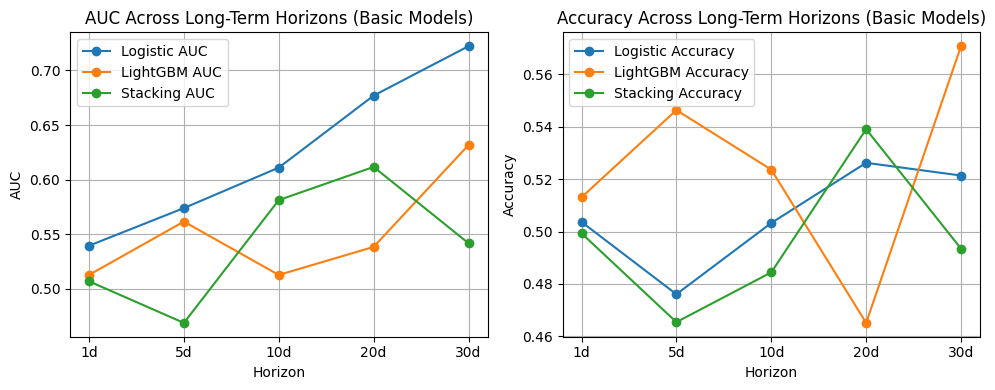

In [ ]:

data = create_longterm_direction_targets(data)


split_idx = int(len(data) * 0.8)
train_data = data.iloc[:split_idx]
test_data = data.iloc[split_idx:]



df_basic = train_basic_models_longterm(train_data, test_data, feature_cols)


plot_basic_model_results(df_basic)


In [ ]:
print(df_basic[['Horizon', 'Logistic_Acc', 'LightGBM_Acc', 'Stacking_Acc']])


  Horizon  Logistic_Acc  LightGBM_Acc  Stacking_Acc
0      1d      0.503657      0.513028      0.499329
1      5d      0.476094      0.546280      0.465460
2     10d      0.503246      0.523584      0.484427
3     20d      0.526177      0.465178      0.538996
4     30d      0.521338      0.570633      0.493457


In [ ]:
print(df_basic[['Horizon', 'Logistic_AUC',
                'LightGBM_AUC',
                'Stacking_AUC',]])

  Horizon  Logistic_AUC  LightGBM_AUC  Stacking_AUC
0      1d      0.539497      0.512736      0.506891
1      5d      0.573944      0.561581      0.468798
2     10d      0.611009      0.512701      0.581272
3     20d      0.676960      0.538419      0.611633
4     30d      0.722243      0.631681      0.541755


### MLP

In [ ]:
#  Train MLP separately on long-term horizons
def build_mlp(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['AUC'])
    return model

def train_mlp_longterm(train_data, test_data, feature_cols, days=[1, 5, 10, 20, 30], epochs=10, batch_size=128):
    results = []
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_data[feature_cols])
    X_test = scaler.transform(test_data[feature_cols])
    input_dim = X_train.shape[1]

    for d in days:
        label_col = f'target_{d}d'
        y_train = train_data[label_col].values
        y_test = test_data[label_col].values

        model = build_mlp(input_dim)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_split=0.1)

        y_pred_prob = model.predict(X_test).ravel()
        auc = roc_auc_score(y_test, y_pred_prob)
        acc = accuracy_score(y_test, y_pred_prob > 0.5)

        results.append({
            'Horizon': f'{d}d',
            'MLP_AUC': auc,
            'MLP_Acc': acc
        })

    return pd.DataFrame(results)

In [ ]:
df_mlp = train_mlp_longterm(train_data, test_data, feature_cols)
print(df_mlp)

plot_mlp_results(df_mlp)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17280/17280 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17280/17280 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17280/17280 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17280/17280 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step
  Horizon   MLP_AUC   MLP_Acc
0      1d  0.514606  0.503941
1      5d  0.500979  0.473942
2     10d  0.595264  0.499989
3     20d  0.352369  0.522806
4     30d  0.500295  0.519511


NameError: name 'plot_mlp_results' is not defined

In [ ]:
data = create_longterm_direction_targets(data)

In [ ]:

split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]


In [ ]:
plot_longterm_results(df_longterm)


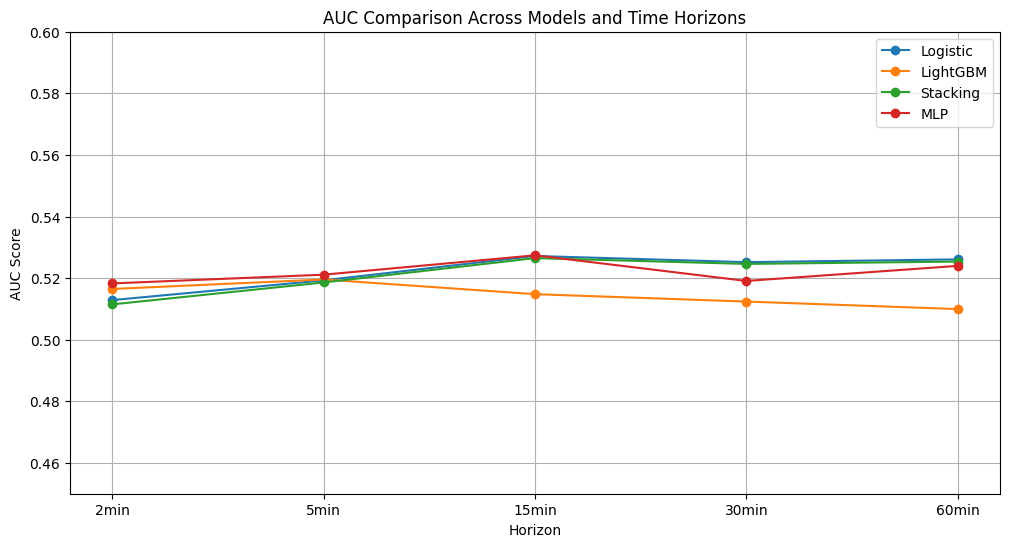

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_all['Horizon'], df_all['Logistic_AUC'], label='Logistic', marker='o')
plt.plot(df_all['Horizon'], df_all['LightGBM_AUC'], label='LightGBM', marker='o')
plt.plot(df_all['Horizon'], df_all['Stacking_AUC'], label='Stacking', marker='o')
plt.plot(df_all['Horizon'], df_all['MLP_AUC'], label='MLP', marker='o')

plt.title('AUC Comparison Across Models and Time Horizons')
plt.xlabel('Horizon')
plt.ylabel('AUC Score')
plt.ylim(0.45, 0.6)
plt.legend()
plt.grid(True)
plt.show()


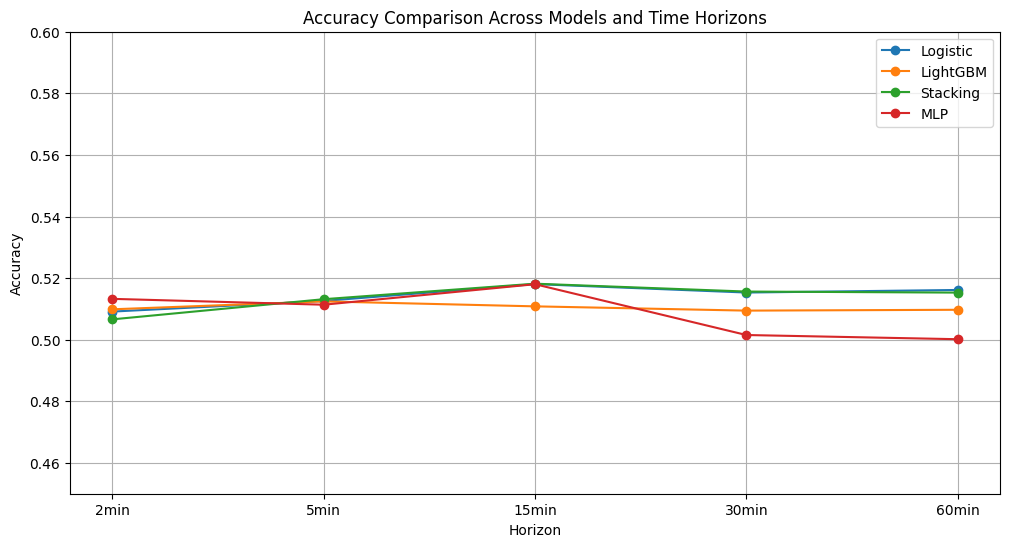

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_all['Horizon'], df_all['Logistic_Acc'], label='Logistic', marker='o')
plt.plot(df_all['Horizon'], df_all['LightGBM_Acc'], label='LightGBM', marker='o')
plt.plot(df_all['Horizon'], df_all['Stacking_Acc'], label='Stacking', marker='o')
plt.plot(df_all['Horizon'], df_all['MLP_Acc'], label='MLP', marker='o')

plt.title('Accuracy Comparison Across Models and Time Horizons')
plt.xlabel('Horizon')
plt.ylabel('Accuracy')
plt.ylim(0.45, 0.6)
plt.legend()
plt.grid(True)
plt.show()


## Part 4: Price Predicting

In [ ]:
data['close_t5'] = data['close'].shift(-5)
data['log_return_5min'] = np.log(data['close_t5'] / data['close'])

data = data.dropna(subset=['log_return_5min'])

features = [
    'close', 'macd', 'macd_diff', 'rsi_14', 'sma_10', 'bb_ratio',
    'atr', 'obv', 'log_volume', 'mean_volume_10', 'volume_ratio',
    'rolling_std_5', 'hour', 'dayofweek'
]
target = 'log_return_5min'



In [ ]:
# Split the data
train_size = 0.8  # 80% and 20%
split_index = int(len(data) * train_size)

train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

### LGBM

In [ ]:
model = LGBMRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred_return = model.predict(X_test)

# Back to actual price
actual_price_lgbm = X_test['close'].values * np.exp(y_test.values)
predicted_price_lgbm = X_test['close'].values * np.exp(y_pred_return)

# Evaluate
rmse = mean_squared_error(actual_price_lgbm, predicted_price_lgbm) ** 0.5
r2 = r2_score(actual_price_lgbm, predicted_price_lgbm)
print(f"LightGBM RMSE (price): {rmse:.6f}")
print(f"LightGBM R² (price): {r2:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029049 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3091
[LightGBM] [Info] Number of data points in the train set: 2211832, number of used features: 14
[LightGBM] [Info] Start training from score 0.000005
LightGBM RMSE (price): 132.257541
LightGBM R² (price): 0.9999


### BRNN

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features])
y = data['log_return_5min'].values

# window
def create_sequences(X, y, window=10):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, window=10)
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

In [ ]:
model = Sequential([
    Bidirectional(SimpleRNN(64, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(X_train, y_train, validation_split=0.1, epochs=30, batch_size=128, callbacks=[early_stop], verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
15552/15552 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - loss: 0.0137 - val_loss: 4.2317e-06
Epoch 2/30
15552/15552 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 7.0377e-06 - val_loss: 2.7603e-06
Epoch 3/30
15552/15552 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 5.9412e-06 - val_loss: 2.6784e-06
Epoch 4/30
15552/15552 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 5.8112e-06 - val_loss: 2.6088e-06
Epoch 5/30
15552/15552 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 5.8668e-06 - val_loss: 2.7395e-06
Epoch 6/30
15552/15552 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 5.9008e-06 - val_loss: 2.6977e-06
Epoch 7/30
15552/15552 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - loss: 5.8042e-06 - val_loss: 2.9942e-06


In [ ]:
y_pred = model.predict(X_test).ravel()
price_input = data['close'].values[-len(y_pred)-10:][-len(y_pred):]

actual_price_brnn = price_input * np.exp(y_test)
predicted_price_brnn = price_input * np.exp(y_pred)

rmse = mean_squared_error(actual_price_brnn, predicted_price_brnn) ** 0.5
r2 = r2_score(actual_price_brnn, predicted_price_brnn)
print(f"BRNN RMSE (price): {rmse:.6f}")
print(f"BRNN R² (price): {r2:.4f}")


17280/17280 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step
BRNN RMSE (price): 131.547129
BRNN R² (price): 0.9999


In [ ]:
import matplotlib.pyplot as plt

def plot_price_prediction(actual_price, predicted_price, title="Price Prediction (5-min ahead)", sample_size=300):
    plt.figure(figsize=(12, 6))
    plt.plot(actual_price[:sample_size], label='True Price', linewidth=2)
    plt.plot(predicted_price[:sample_size], label='Predicted Price', linewidth=2)
    plt.title(title)
    plt.xlabel("Time Steps")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()


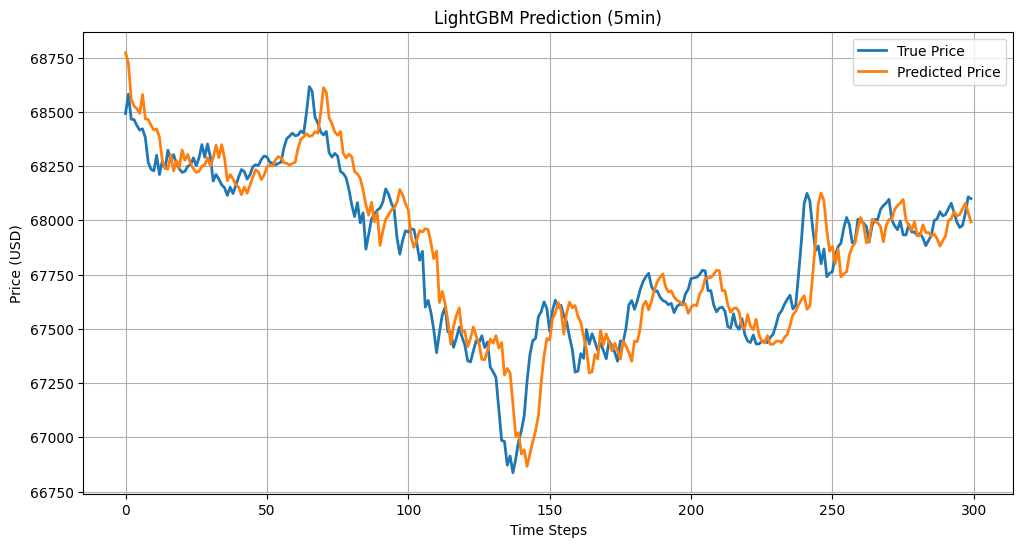

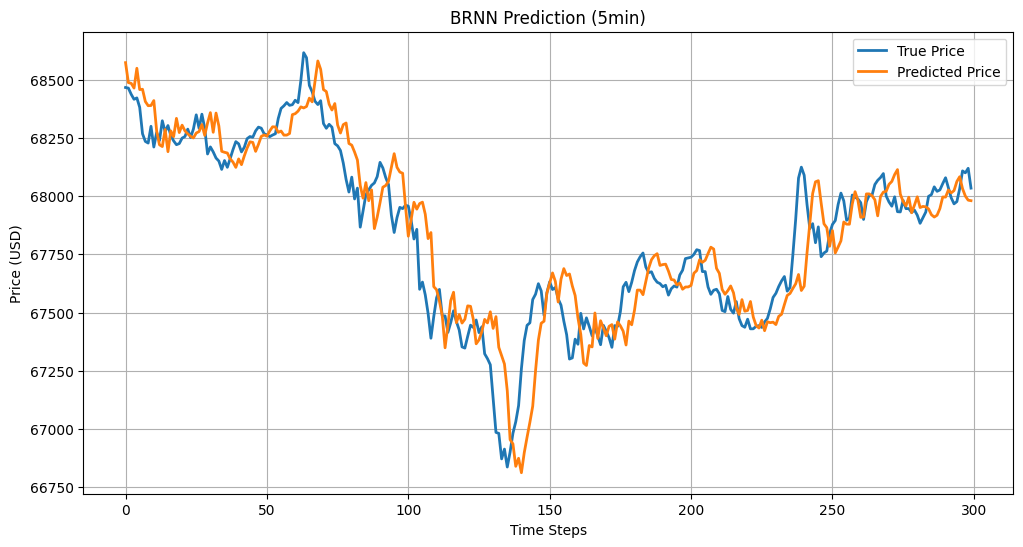

In [ ]:
plot_price_prediction(actual_price_lgbm, predicted_price_lgbm, title="LightGBM Prediction (5min)")

plot_price_prediction(actual_price_brnn, predicted_price_brnn, title="BRNN Prediction (5min)")


## Streamlit File

In [ ]:
import pickle

# Save LGBM
with open('price_model_lgbm_5min.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [ ]:
from google.colab import files
files.download('price_model_lgbm_5min.pkl')
files.download('scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.losses import MeanSquaredError

model.compile(optimizer='adam', loss=MeanSquaredError())
model.save('price_model_brnn_5min.h5')


In [ ]:
from google.colab import files
files.download('price_model_brnn_5min.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>